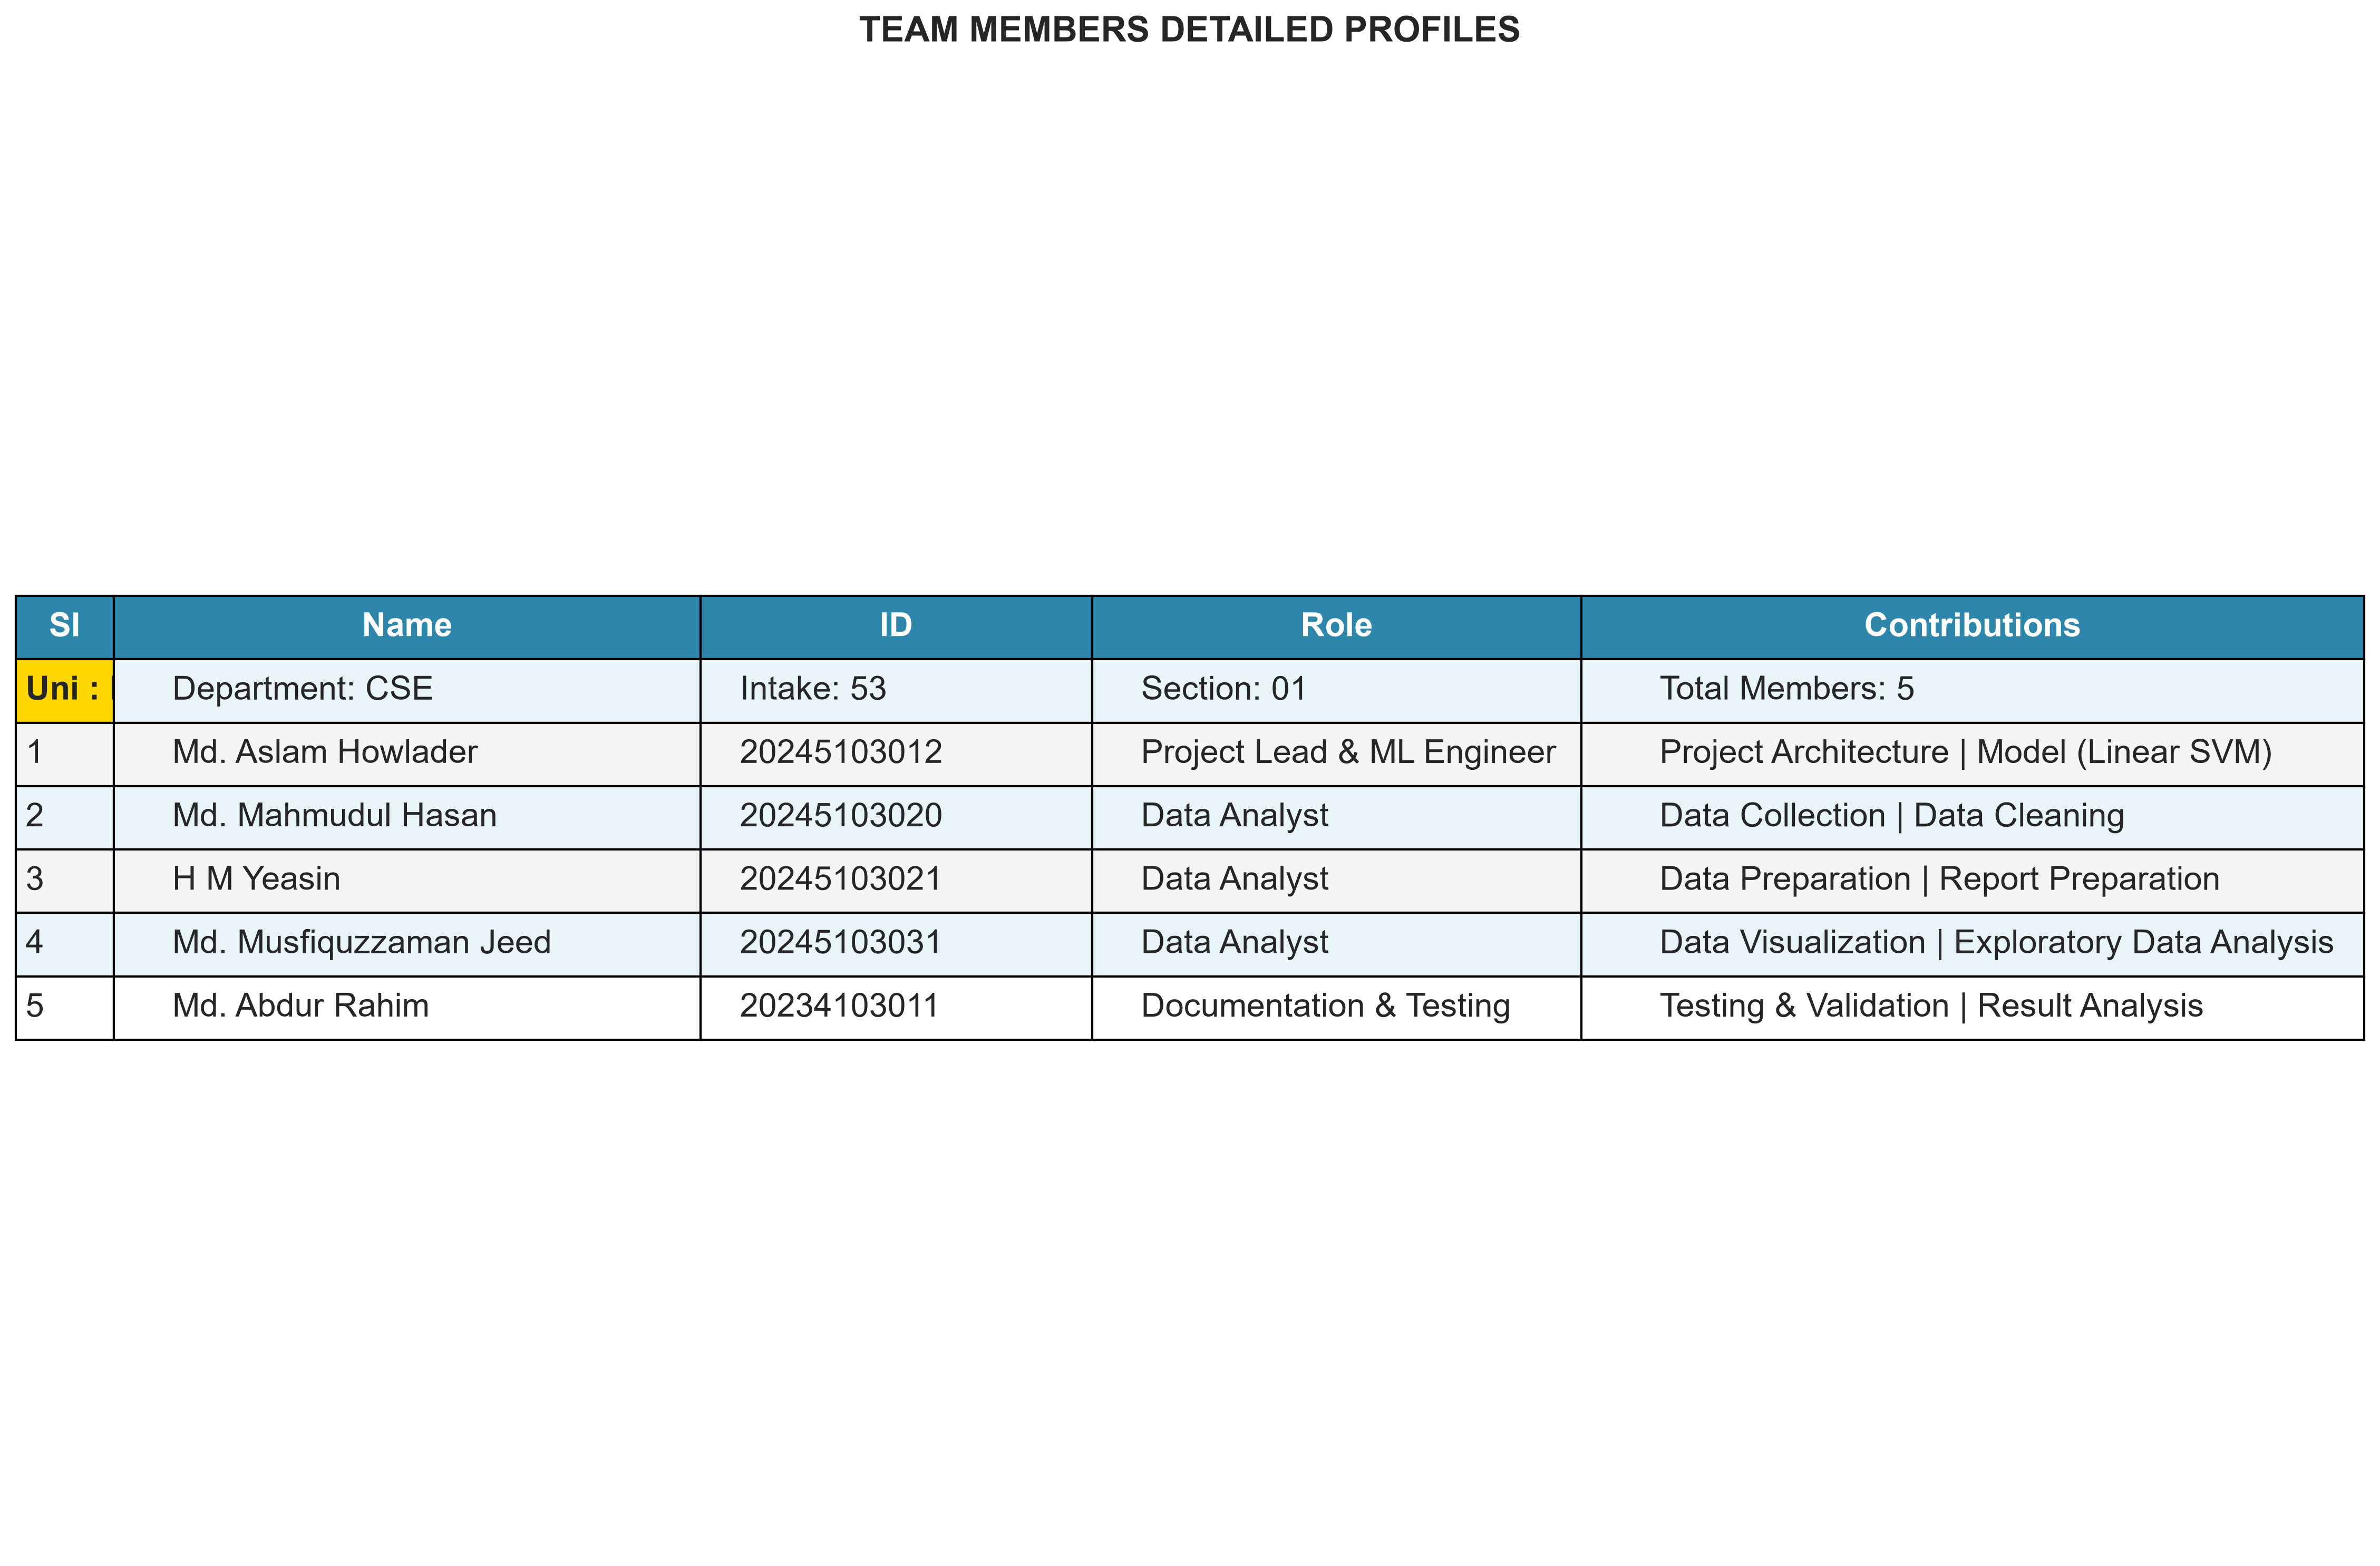

In [182]:
from IPython.display import Image, display
display(Image('team_members_table.png'))

In [187]:
# ============================================
# CELL 1: IMPORT LIBRARIES
# ===========================================

import pandas as pd
import re
import nltk
import pickle
import warnings

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt


from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, classification_report, confusion_matrix,
                            ConfusionMatrixDisplay)

# Download NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("==>> Libraries imported successfully!")

==>> Libraries imported successfully!


In [183]:
# ============================================
# CELL 2: LOAD DATASET
# ============================================
# Load the dataset
df = pd.read_csv('sentimentdataset.csv')
print(f"==> Dataset loaded successfully!")


==> Dataset loaded successfully!


In [184]:
print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Columns: {df.columns.tolist()}")

   Shape: 732 rows × 15 columns
   Columns: ['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']


In [69]:
# ============================================
# CELL 3: EXPLORE DATASET - head()
# ============================================

print("First 5 rows:")
df.head()

First 5 rows:


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [70]:
# ============================================
# CELL 4: EXPLORE DATASET - tail()
# ============================================
print("Last 5 rows:")
df.tail()

Last 5 rows:


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
727,728,732,Collaborating on a science project that receiv...,Happy,2017-08-18 18:20:00,ScienceProjectSuccessHighSchool,Facebook,#ScienceFairWinner #HighSchoolScience,20.0,39.0,UK,2017,8,18,18
728,729,733,Attending a surprise birthday party organized ...,Happy,2018-06-22 14:15:00,BirthdayPartyJoyHighSchool,Instagram,#SurpriseCelebration #HighSchoolFriendship,25.0,48.0,USA,2018,6,22,14
729,730,734,Successfully fundraising for a school charity ...,Happy,2019-04-05 17:30:00,CharityFundraisingTriumphHighSchool,Twitter,#CommunityGiving #HighSchoolPhilanthropy,22.0,42.0,Canada,2019,4,5,17
730,731,735,"Participating in a multicultural festival, cel...",Happy,2020-02-29 20:45:00,MulticulturalFestivalJoyHighSchool,Facebook,#CulturalCelebration #HighSchoolUnity,21.0,43.0,UK,2020,2,29,20
731,732,736,Organizing a virtual talent show during challe...,Happy,2020-11-15 15:15:00,VirtualTalentShowSuccessHighSchool,Instagram,#VirtualEntertainment #HighSchoolPositivity,24.0,47.0,USA,2020,11,15,15


In [189]:
# ============================================
# CELL 5: EXPLORE DATASET - shape
# ============================================
print(f"Dataset Shape:")
print(f"   Rows: {df.shape[0]}")
print(f"   Columns: {df.shape[1]}")


Dataset Shape:
   Rows: 732
   Columns: 15


In [72]:
# ============================================
# CELL 6: EXPLORE DATASET - info()
# ============================================
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    str    
 3   Sentiment     732 non-null    str    
 4   Timestamp     732 non-null    str    
 5   User          732 non-null    str    
 6   Platform      732 non-null    str    
 7   Hashtags      732 non-null    str    
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    str    
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), str(7)
memory usage: 85.9 KB


In [73]:
# ============================================
# CELL 7: EXPLORE DATASET - describe()
# ============================================
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Unnamed: 0.1,Unnamed: 0,Retweets,Likes,Year,Month,Day,Hour
count,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000
mean,366.464481,369.740437,21.508197,42.901639,2020.471311,6.122951,15.497268,15.521858
std,211.513936,212.428936,7.061286,14.089848,2.802285,3.411763,8.474553,4.113414
min,0.000000,0.000000,5.000000,10.000000,2010.000000,1.000000,1.000000,0.000000
25%,183.750000,185.750000,17.750000,34.750000,2019.000000,3.000000,9.000000,13.000000
50%,366.500000,370.500000,22.000000,43.000000,2021.000000,6.000000,15.000000,16.000000
75%,549.250000,553.250000,25.000000,50.000000,2023.000000,9.000000,22.000000,19.000000
max,732.000000,736.000000,40.000000,80.000000,2023.000000,12.000000,31.000000,23.000000


In [74]:
# ============================================
# CELL 8: EXPLORE DATASET - Additional
# ============================================
print("\nUnique values per column:")
for col in df.columns:
    print(f"   {col}: {df[col].nunique()} unique values")


Unique values per column:
   Unnamed: 0.1: 732 unique values
   Unnamed: 0: 732 unique values
   Text: 707 unique values
   Sentiment: 279 unique values
   Timestamp: 683 unique values
   User: 685 unique values
   Platform: 4 unique values
   Hashtags: 697 unique values
   Retweets: 26 unique values
   Likes: 38 unique values
   Country: 115 unique values
   Year: 14 unique values
   Month: 12 unique values
   Day: 31 unique values
   Hour: 22 unique values


In [75]:
# ============================================
# CELL 9: KEEP ONLY 4 COLUMNS (REMOVE ALL OTHERS)
# ============================================

# Keep ONLY these 4 columns
columns_to_keep = ['Text', 'Sentiment', 'Platform', 'Country']

# All other columns will be dropped
columns_to_drop = [col for col in df.columns if col not in columns_to_keep]

print(f"Columns to drop: {columns_to_drop}")
print(f"Columns to keep: {columns_to_keep}")

# Remove unnecessary columns (keep only 4)
df = df[columns_to_keep].copy()

print(f"\n Shape after keeping only 4 columns: {df.shape}")
print(f"   Remaining columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())

Columns to drop: ['Unnamed: 0.1', 'Unnamed: 0', 'Timestamp', 'User', 'Hashtags', 'Retweets', 'Likes', 'Year', 'Month', 'Day', 'Hour']
Columns to keep: ['Text', 'Sentiment', 'Platform', 'Country']

 Shape after keeping only 4 columns: (732, 4)
   Remaining columns: ['Text', 'Sentiment', 'Platform', 'Country']

First 5 rows:
                                                Text    Sentiment  \
0   Enjoying a beautiful day at the park!        ...   Positive     
1   Traffic was terrible this morning.           ...   Negative     
2   Just finished an amazing workout! 💪          ...   Positive     
3   Excited about the upcoming weekend getaway!  ...   Positive     
4   Trying out a new recipe for dinner tonight.  ...   Neutral      

      Platform       Country  
0    Twitter       USA        
1    Twitter       Canada     
2   Instagram    USA          
3    Facebook      UK         
4   Instagram     Australia   


In [116]:
df

,Text,Sentiment,Platform,Country,Clean_Text,Sentiment_Category,Sentiment_Label
0,Enjoying a beautiful day at the park! ...,Positive,Twitter,USA,enjoying beautiful day park,Positive,2
1,Traffic was terrible this morning. ...,Negative,Twitter,Canada,traffic terrible morning,Negative,0
2,Just finished an amazing workout! 💪 ...,Positive,Instagram,USA,finished amazing workout,Positive,2
3,Excited about the upcoming weekend getaway! ...,Positive,Facebook,UK,excited upcoming weekend getaway,Positive,2
4,Trying out a new recipe for dinner tonight. ...,Neutral,Instagram,Australia,trying new recipe dinner tonight,Neutral,1
...,...,...,...,...,...,...,...
727,Collaborating on a science project that receiv...,Happy,Facebook,UK,collaborating science project received recogni...,Neutral,1
728,Attending a surprise birthday party organized ...,Happy,Instagram,USA,attending surprise birthday party organized fr...,Neutral,1
729,Successfully fundraising for a school charity ...,Happy,Twitter,Canada,successfully fundraising school charity initia...,Neutral,1
730,"Participating in a multicultural festival, cel...",Happy,Facebook,UK,participating multicultural festival celebrati...,Neutral,1


In [117]:
# ============================================
# CELL 10: CHECK MISSING VALUES
# ============================================
print("Missing values per column:")
print(df.isnull().sum())

# Handle missing values
missing_cols = df.columns[df.isnull().any()].tolist()
if missing_cols:
    print(f"\n Columns with missing values: {missing_cols}")
    print("  Handling missing values...")

    # Drop rows with missing Text or Sentiment
    df = df.dropna(subset=['Text', 'Sentiment'])

    # Fill other missing values

    if 'Platform' in df.columns:
        df['Platform'] = df['Platform'].fillna('unknown')
    if 'Country' in df.columns:
        df['Country'] = df['Country'].fillna('unknown')


    print(f"Shape after handling missing values: {df.shape}")
else:
    print(" No missing values found!")

Missing values per column:
Text                  0
Sentiment             0
Platform              0
Country               0
Clean_Text            0
Sentiment_Category    0
Sentiment_Label       0
dtype: int64
 No missing values found!


In [78]:
# ============================================
# CELL 11: CHECK DUPLICATES
# ============================================
# Check for duplicate rows based on Text
duplicate_count = df.duplicated(subset=['Text']).sum()
print(f"Duplicate rows based on 'Text': {duplicate_count}")

# Remove duplicates if any
if duplicate_count > 0:
    print("Removing duplicate rows...")
    df = df.drop_duplicates(subset=['Text'])
    print(f"Shape after removing duplicates: {df.shape}")
else:
    print("No duplicates found!")

Duplicate rows based on 'Text': 25
Removing duplicate rows...
Shape after removing duplicates: (707, 4)


In [79]:
# ============================================
# CELL 12: TEXT PREPROCESSING - Define Function
# ============================================


def preprocess_text(text):

    if not isinstance(text, str):
        text = str(text)

    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # 4. Remove @mentions
    text = re.sub(r'@\w+', '', text)

    # 5. Remove hashtags (keep the content)
    text = re.sub(r'#(\w+)', r'\1', text)

    # 6. Remove emojis
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text)

    # 7. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 8. Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 9. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 10. Tokenization
    tokens = text.split()

    # 11. Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    # 12. Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Join tokens back into text
    clean_text = ' '.join(tokens)

    return clean_text

print("=>Text preprocessing function defined!")

=>Text preprocessing function defined!


In [119]:
# ============================================
# CELL 13: TEXT PREPROCESSING - Apply
# ============================================
print("Applying text preprocessing to all texts...")
df['Clean_Text'] = df['Text'].apply(preprocess_text)

# Remove empty texts after preprocessing
empty_texts = df[df['Clean_Text'].str.len() == 0].shape[0]
if empty_texts > 0:
    print(f"Found {empty_texts} empty texts after preprocessing. Removing...")
    df = df[df['Clean_Text'].str.len() > 0]

print(f"Preprocessing complete. Shape: {df.shape}")

# Show sample of preprocessing
print("\n Sample of preprocessing:")
sample_idx = 0
print(f"Original: {df['Text'].iloc[sample_idx]}")
print(f"Cleaned:  {df['Clean_Text'].iloc[sample_idx]}")

Applying text preprocessing to all texts...
Preprocessing complete. Shape: (707, 7)

 Sample of preprocessing:
Original:  Enjoying a beautiful day at the park!              
Cleaned:  enjoying beautiful day park


In [81]:
# ============================================
# CELL 14: CONVERT EMOTION → SENTIMENT
# ============================================
# Clean up sentiment column
df['Sentiment'] = df['Sentiment'].str.strip()

# Get unique emotions
unique_emotions = df['Sentiment'].unique()
print(f"Unique emotion labels found: {len(unique_emotions)}")
print(f"Examples: {list(unique_emotions)[:15]}...")

# Define sentiment mapping
positive_emotions = {
    'positive', 'joy', 'happiness', 'excitement', 'gratitude', 'pride', 'love',
    'awe', 'serenity', 'contentment', 'enthusiasm', 'admiration', 'affection',
    'amusement', 'anticipation', 'appreciation', 'calmness', 'confidence',
    'empowerment', 'enjoyment', 'hope', 'inspiration', 'motivation', 'optimism',
    'satisfaction', 'surprise', 'thrill', 'tranquility', 'zest', 'fulfillment',
    'elation', 'euphoria', 'overjoyed', 'playful', 'grateful', 'free-spirited',
    'joyfulreunion', 'celebration', 'accomplishment', 'relief', 'blessed',
    'adventure', 'wonder', 'captivation', 'hypnotic', 'serene'
}

negative_emotions = {
    'negative', 'anger', 'sadness', 'fear', 'grief', 'despair', 'loneliness',
    'jealousy', 'frustration', 'bitterness', 'regret', 'anxiety', 'hate',
    'disgust', 'resentment', 'helplessness', 'intimidation', 'envy', 'boredom',
    'disappointed', 'desolation', 'devastated', 'heartbreak', 'isolation',
    'sorrow', 'suffering', 'exhaustion', 'melancholy', 'numbness', 'overwhelmed',
    'apprehensive', 'dismissive', 'desperation', 'fearful', 'sad', 'bad', 'loss'
}

neutral_emotions = {
    'neutral', 'indifference', 'curiosity', 'reflection', 'contemplation',
    'confusion', 'ambivalence', 'nostalgia', 'pensive', 'contemplative',
    'neutrality', 'curiosity'
}

def map_emotion_to_sentiment(emotion):
    """Map emotion labels to Positive, Negative, or Neutral"""
    emotion = emotion.lower().strip()

    if emotion in positive_emotions:
        return 'Positive'
    elif emotion in negative_emotions:
        return 'Negative'
    elif emotion in neutral_emotions:
        return 'Neutral'
    else:
        # Default to Neutral if unknown
        return 'Neutral'

# Apply mapping
df['Sentiment_Category'] = df['Sentiment'].apply(map_emotion_to_sentiment)

# Check distribution
print("\nSentiment Category Distribution:")
print(df['Sentiment_Category'].value_counts())
print("\nPercentage Distribution:")
print(df['Sentiment_Category'].value_counts(normalize=True) * 100)

Unique emotion labels found: 191
Examples: ['Positive', 'Negative', 'Neutral', 'Anger', 'Fear', 'Sadness', 'Disgust', 'Happiness', 'Joy', 'Love', 'Amusement', 'Enjoyment', 'Admiration', 'Affection', 'Awe']...

Sentiment Category Distribution:
Sentiment_Category
Positive    304
Neutral     260
Negative    143
Name: count, dtype: int64

Percentage Distribution:
Sentiment_Category
Positive    42.998586
Neutral     36.775106
Negative    20.226308
Name: proportion, dtype: float64


In [120]:
df

,Text,Sentiment,Platform,Country,Clean_Text,Sentiment_Category,Sentiment_Label
0,Enjoying a beautiful day at the park! ...,Positive,Twitter,USA,enjoying beautiful day park,Positive,2
1,Traffic was terrible this morning. ...,Negative,Twitter,Canada,traffic terrible morning,Negative,0
2,Just finished an amazing workout! 💪 ...,Positive,Instagram,USA,finished amazing workout,Positive,2
3,Excited about the upcoming weekend getaway! ...,Positive,Facebook,UK,excited upcoming weekend getaway,Positive,2
4,Trying out a new recipe for dinner tonight. ...,Neutral,Instagram,Australia,trying new recipe dinner tonight,Neutral,1
...,...,...,...,...,...,...,...
727,Collaborating on a science project that receiv...,Happy,Facebook,UK,collaborating science project received recogni...,Neutral,1
728,Attending a surprise birthday party organized ...,Happy,Instagram,USA,attending surprise birthday party organized fr...,Neutral,1
729,Successfully fundraising for a school charity ...,Happy,Twitter,Canada,successfully fundraising school charity initia...,Neutral,1
730,"Participating in a multicultural festival, cel...",Happy,Facebook,UK,participating multicultural festival celebrati...,Neutral,1


In [82]:
# ============================================
# CELL 15: ENCODE LABELS
# ============================================
# Negative → 0, Neutral → 1, Positive → 2
sentiment_mapping = {
    'Negative': 0,
    'Neutral': 1,
    'Positive': 2
}

df['Sentiment_Label'] = df['Sentiment_Category'].map(sentiment_mapping)

# Check encoding
print("Label Encoding Distribution:")
print(df['Sentiment_Label'].value_counts().sort_index())
print("\nLabel mapping:")
print(sentiment_mapping)

Label Encoding Distribution:
Sentiment_Label
0    143
1    260
2    304
Name: count, dtype: int64

Label mapping:
{'Negative': 0, 'Neutral': 1, 'Positive': 2}


In [83]:
# ============================================
# CELL 16: TF-IDF VECTORIZATION
# ============================================
# Feature matrix X (text features) and target y (labels)
X_text = df['Clean_Text'].values
y = df['Sentiment_Label'].values

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,          # Limit features for efficiency
    min_df=2,                    # Ignore terms that appear in less than 2 documents
    max_df=0.8,                  # Ignore terms that appear in more than 80% of documents
    ngram_range=(1, 2),          # Unigrams and bigrams
    sublinear_tf=True            # Use 1+log(tf) instead of raw tf
)

# Fit and transform
X = tfidf_vectorizer.fit_transform(X_text)

print(f"Feature Matrix Shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")

Feature Matrix Shape: (707, 1288)
Number of features: 1288
Number of samples: 707


In [84]:
# ============================================
# CELL 17: TRAIN-TEST SPLIT (80/20)
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Preserve class distribution
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"\nTraining set class distribution:")
print(pd.Series(y_train).value_counts().sort_index())
print(f"\nTest set class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Training set shape: (565, 1288)
Test set shape: (142, 1288)

Training set class distribution:
0    114
1    208
2    243
Name: count, dtype: int64

Test set class distribution:
0    29
1    52
2    61
Name: count, dtype: int64


In [85]:
# ============================================
# CELL 18: TRAIN LINEAR SVM MODEL
# ============================================
print("Training Linear SVM model...")
svm_model = LinearSVC(
    C=1.0,
    class_weight='balanced',
    random_state=42,
    max_iter=1000,
    dual=False
)

svm_model.fit(X_train, y_train)
print("Model training complete!")

Training Linear SVM model...
Model training complete!


In [191]:
# ============================================
# CELL 19: PREDICT TEST DATA
# ============================================
y_pred = svm_model.predict(X_test)
print("Predictions complete!")
print(f"Predicted labels: {y_pred[:10]}")
print(f"Actual labels:    {y_test[:10]}")

Predictions complete!
Predicted labels: [2 2 1 2 1 2 2 1 2 1]
Actual labels:    [2 2 1 2 1 2 2 2 2 1]


In [88]:
# ============================================
# CELL 20: EVALUATE PERFORMANCE - Metrics
# ============================================
print("="*60)
print("MODEL EVALUATION")
print("="*60)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

MODEL EVALUATION

Accuracy:  0.6972
Precision: 0.6966
Recall:    0.6972
F1-Score:  0.6931


In [89]:
# ============================================
# CELL 21: CLASSIFICATION REPORT
# ============================================
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive']))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.82      0.79      0.81        29
     Neutral       0.65      0.54      0.59        52
    Positive       0.68      0.79      0.73        61

    accuracy                           0.70       142
   macro avg       0.72      0.71      0.71       142
weighted avg       0.70      0.70      0.69       142




CONFUSION MATRIX
[[23  2  4]
 [ 5 28 19]
 [ 0 13 48]]


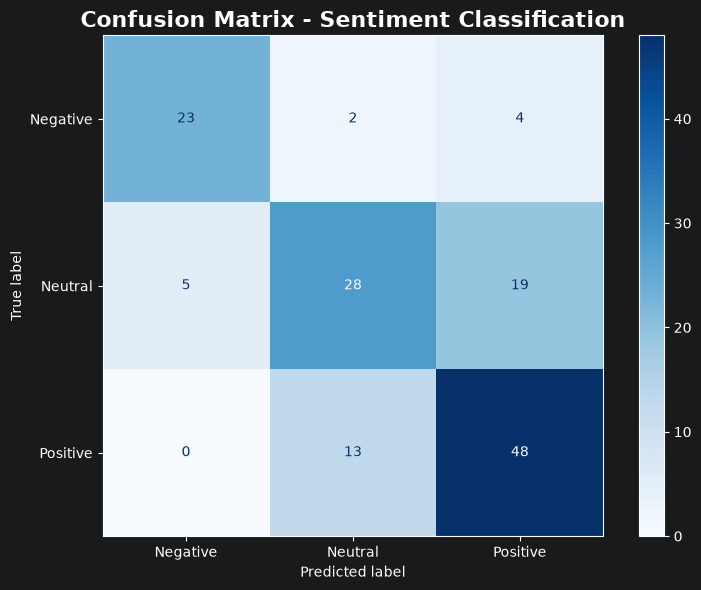

In [91]:
# ============================================
# CELL 22: CONFUSION MATRIX
# ============================================
cm = confusion_matrix(y_test, y_pred)
print("\n" + "="*60)
print("CONFUSION MATRIX")
print("="*60)
print(cm)

# Visualize Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Neutral', 'Positive'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Sentiment Classification', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [93]:
# ============================================
# CELL 23: SAVE MODELS
# ============================================
print("\n" + "="*60)
print("SAVING MODELS")
print("="*60)

# Save TF-IDF Vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print("✓ TF-IDF Vectorizer saved as 'tfidf_vectorizer.pkl'")

# Save Linear SVM Model
with open('svm_sentiment_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)
print("✓ SVM Model saved as 'svm_sentiment_model.pkl'")

# Save the sentiment mapping
with open('sentiment_mapping.pkl', 'wb') as f:
    pickle.dump(sentiment_mapping, f)
print("✓ Sentiment mapping saved as 'sentiment_mapping.pkl'")

# Save the processed dataset
df.to_csv('processed_sentiment_data.csv', index=False)
print("✓ Processed dataset saved as 'processed_sentiment_data.csv'")


SAVING MODELS
✓ TF-IDF Vectorizer saved as 'tfidf_vectorizer.pkl'
✓ SVM Model saved as 'svm_sentiment_model.pkl'
✓ Sentiment mapping saved as 'sentiment_mapping.pkl'
✓ Processed dataset saved as 'processed_sentiment_data.csv'


In [94]:
# ============================================
# CELL 24: PREDICT NEW TEXT
# ============================================
def predict_sentiment(text, model, vectorizer, mapping):
    """
    Function to predict sentiment of a new text
    """
    # Preprocess the text
    cleaned_text = preprocess_text(text)

    # Vectorize
    text_vector = vectorizer.transform([cleaned_text])

    # Predict
    prediction = model.predict(text_vector)[0]

    # Get sentiment label
    sentiment_label = {v: k for k, v in mapping.items()}[prediction]

    return sentiment_label, prediction

# Test the prediction function
print("\n" + "="*60)
print("TESTING PREDICTION ON NEW TEXTS")
print("="*60)

test_texts = [
    "I absolutely love this beautiful weather! ",
    "This is the worst day of my life, I'm so sad.",
    "The movie was okay, nothing special.",
    "I'm feeling incredibly excited about my new job!",
    "This traffic is making me so frustrated.",
    "Just another ordinary day, nothing much to say.",
    "I'm so angry at the injustice happening in our society!",
    "Feeling grateful for all the support from my friends."
]

print("\nTesting on sample texts:\n")
for text in test_texts:
    sentiment, label = predict_sentiment(text, svm_model, tfidf_vectorizer, sentiment_mapping)
    print(f"Text: {text}")
    print(f"Predicted Sentiment: {sentiment} (Label: {label})")
    print("-" * 60)


TESTING PREDICTION ON NEW TEXTS

Testing on sample texts:

Text: I absolutely love this beautiful weather! 
Predicted Sentiment: Negative (Label: 0)
------------------------------------------------------------
Text: This is the worst day of my life, I'm so sad.
Predicted Sentiment: Positive (Label: 2)
------------------------------------------------------------
Text: The movie was okay, nothing special.
Predicted Sentiment: Positive (Label: 2)
------------------------------------------------------------
Text: I'm feeling incredibly excited about my new job!
Predicted Sentiment: Positive (Label: 2)
------------------------------------------------------------
Text: This traffic is making me so frustrated.
Predicted Sentiment: Positive (Label: 2)
------------------------------------------------------------
Text: Just another ordinary day, nothing much to say.
Predicted Sentiment: Positive (Label: 2)
------------------------------------------------------------
Text: I'm so angry at the in

In [44]:
# ============================================
# CELL 26: TOP WORDS BY SENTIMENT
# ============================================
from collections import Counter

def get_top_words_by_sentiment(sentiment_category, n=10):
    """Get top words for a specific sentiment category"""
    texts = df[df['Sentiment_Category'] == sentiment_category]['Clean_Text']
    words = ' '.join(texts).split()
    counter = Counter(words)
    return counter.most_common(n)

print("\n" + "="*60)
print("TOP WORDS BY SENTIMENT CATEGORY")
print("="*60)

for sentiment in ['Positive', 'Neutral', 'Negative']:
    top_words = get_top_words_by_sentiment(sentiment, 10)
    print(f"\n{sentiment} (Top 10):")
    for word, count in top_words:
        print(f"  {word}: {count}")


TOP WORDS BY SENTIMENT CATEGORY

Positive (Top 10):
  new: 28
  friend: 19
  joy: 18
  day: 14
  nature: 14
  laughter: 14
  life: 13
  feeling: 12
  beauty: 12
  moment: 12

Neutral (Top 10):
  life: 15
  new: 14
  moment: 12
  journey: 12
  art: 12
  dream: 11
  exploring: 11
  world: 10
  curiosity: 10
  like: 10

Negative (Top 10):
  despair: 13
  echo: 12
  feeling: 10
  heart: 10
  like: 10
  grief: 8
  loneliness: 8
  day: 8
  storm: 8
  lost: 8


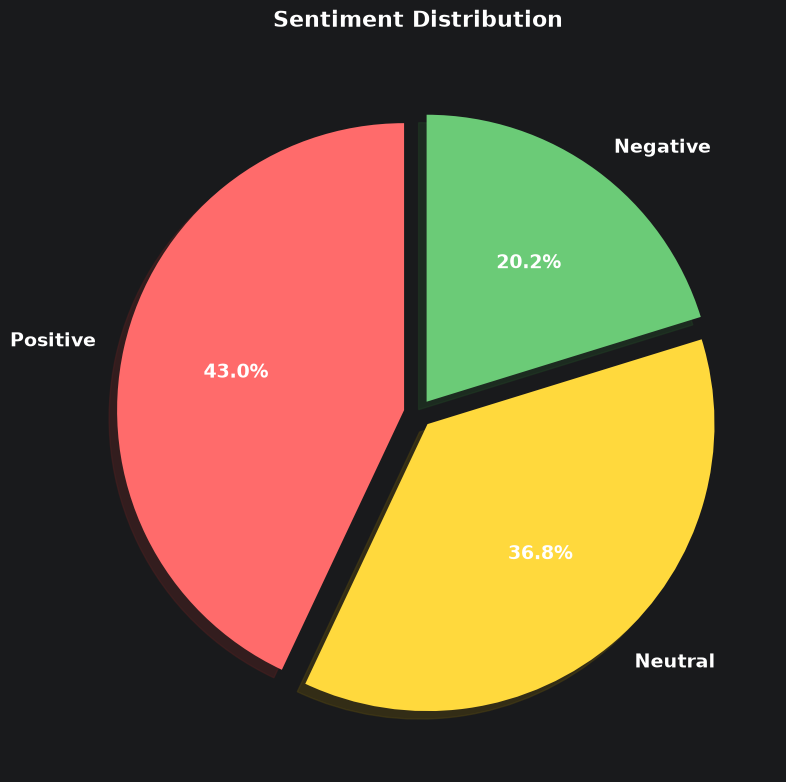

In [96]:
# ============================================
# VISUALIZATION 1: SENTIMENT DISTRIBUTION PIE CHART
# ============================================
import matplotlib.pyplot as plt
import pandas as pd

# Create pie chart
sentiment_counts = df['Sentiment_Category'].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(sentiment_counts.values,
       labels=sentiment_counts.index,
       autopct='%1.1f%%',
       colors=['#ff6b6b', '#ffd93d', '#6bcb77'],
       startangle=90,
       explode=(0.05, 0.05, 0.05),
       shadow=True,
       textprops={'fontsize': 14, 'fontweight': 'bold'})

ax.set_title('Sentiment Distribution', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

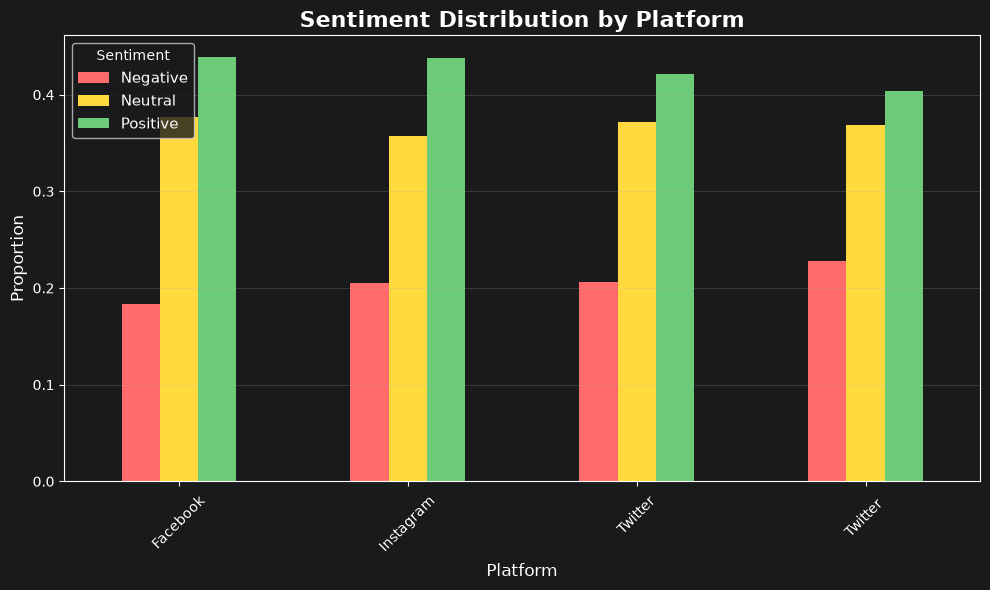

In [97]:
# ============================================
# VISUALIZATION 2: SENTIMENT BY PLATFORM
# ============================================
import matplotlib.pyplot as plt
import pandas as pd

# Create crosstab
platform_sentiment = pd.crosstab(df['Platform'], df['Sentiment_Category'], normalize='index')

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
platform_sentiment.plot(kind='bar', ax=ax, color=['#ff6b6b', '#ffd93d', '#6bcb77'])

ax.set_title('Sentiment Distribution by Platform', fontsize=16, fontweight='bold')
ax.set_xlabel('Platform', fontsize=12)
ax.set_ylabel('Proportion', fontsize=12)
ax.legend(title='Sentiment', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

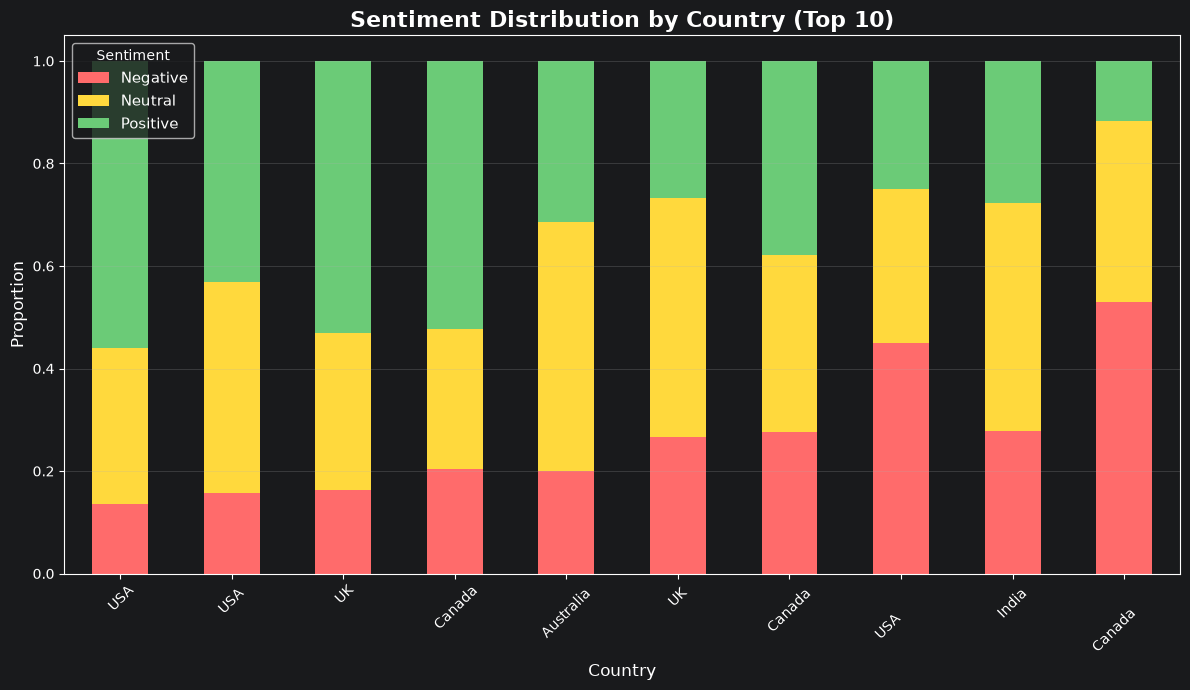

In [99]:
# ============================================
# VISUALIZATION 4: SENTIMENT BY COUNTRY (TOP 10)
# ============================================
import matplotlib.pyplot as plt
import pandas as pd

# Create crosstab
country_sentiment = pd.crosstab(df['Country'], df['Sentiment_Category'], normalize='index')

# Get top 10 countries
top_countries = df['Country'].value_counts().head(10).index
country_sentiment_top = country_sentiment.loc[top_countries]

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
country_sentiment_top.plot(kind='bar', ax=ax, stacked=True,
                          color=['#ff6b6b', '#ffd93d', '#6bcb77'])

ax.set_title('Sentiment Distribution by Country (Top 10)', fontsize=16, fontweight='bold')
ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Proportion', fontsize=12)
ax.legend(title='Sentiment', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

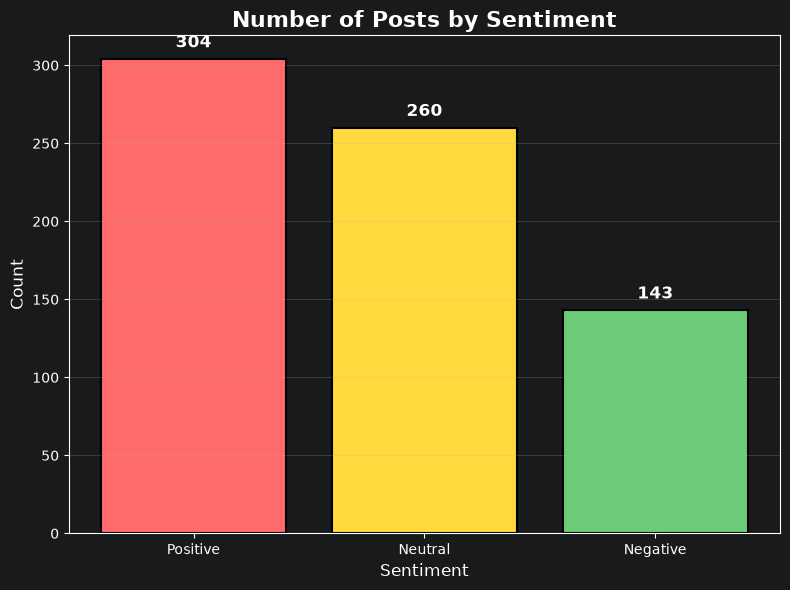

In [100]:
# ============================================
# VISUALIZATION 5: SENTIMENT COUNT BAR CHART
# ============================================
import matplotlib.pyplot as plt

# Get counts
sentiment_counts = df['Sentiment_Category'].value_counts()

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(sentiment_counts.index, sentiment_counts.values,
              color=['#ff6b6b', '#ffd93d', '#6bcb77'],
              edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, value in zip(bars, sentiment_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{value:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Number of Posts by Sentiment', fontsize=16, fontweight='bold')
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

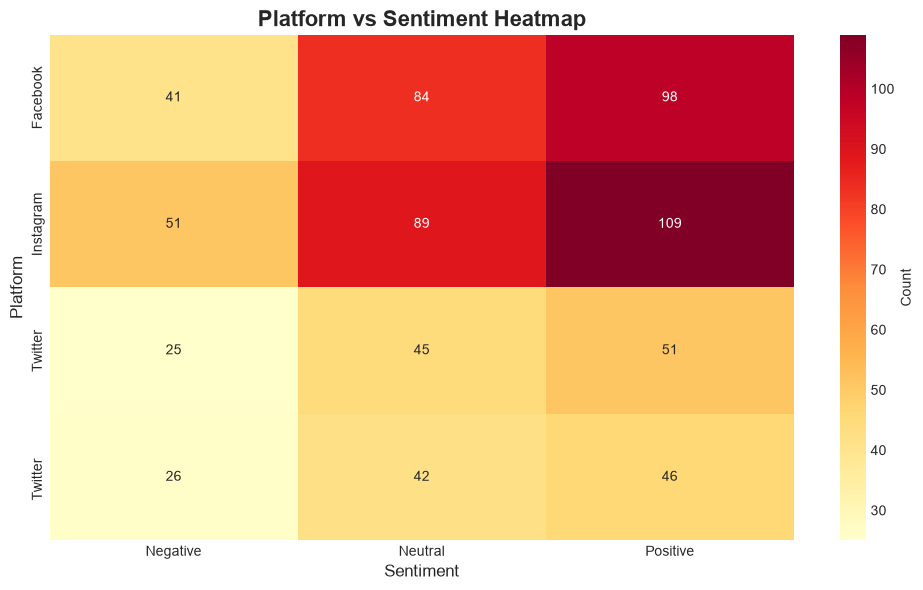

In [121]:
# ============================================
# VISUALIZATION 6: PLATFORM VS SENTIMENT HEATMAP
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create crosstab
platform_sentiment_count = pd.crosstab(df['Platform'], df['Sentiment_Category'])

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(platform_sentiment_count, annot=True, fmt='d', cmap='YlOrRd',
            ax=ax, cbar_kws={'label': 'Count'})

ax.set_title('Platform vs Sentiment Heatmap', fontsize=16, fontweight='bold')
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Platform', fontsize=12)

plt.tight_layout()
plt.show()

In [122]:
# ============================================
# CELL 27: MODEL PERFORMANCE SUMMARY
# ============================================
print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)

print(f"""
┌─────────────────────────────────────┐
│         MODEL PERFORMANCE           │
├─────────────────────────────────────┤
│ Accuracy:    {accuracy:.4f}         │
│ Precision:   {precision:.4f}        │
│ Recall:      {recall:.4f}           │
│ F1-Score:    {f1:.4f}               │
├─────────────────────────────────────┤
│ Training Samples:{X_train.shape[0]:}│
│ Test Samples:    {X_test.shape[0]:,}│
│ Features:         {X.shape[1]:,}    │
└─────────────────────────────────────┘
""")

print("\nSentiment Analysis Pipeline Complete!")
print("All models and files have been saved successfully!")


MODEL PERFORMANCE SUMMARY

┌─────────────────────────────────────┐
│         MODEL PERFORMANCE           │
├─────────────────────────────────────┤
│ Accuracy:    0.6972         │
│ Precision:   0.6966        │
│ Recall:      0.6972           │
│ F1-Score:    0.6931               │
├─────────────────────────────────────┤
│ Training Samples:565│
│ Test Samples:    142│
│ Features:         1,288    │
└─────────────────────────────────────┘


Sentiment Analysis Pipeline Complete!
All models and files have been saved successfully!
